In [1]:
import os
os.environ["KERAS_BACKEND"]="tensorflow"

import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from keras.applications import efficientnet
from keras.layers import TextVectorization
import numpy as np
import re
keras.utils.set_random_seed(67) # :o

In [2]:
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip -qq Flickr8k_Dataset.zip
!unzip -qq Flickr8k_text.zip
!rm Flickr8k_Dataset.zip Flickr8k_text.zip


### ! calls to the terminal, 
### wget is like downloading files followed by link
### unzip is obvious
### -q is quite(does not show download bars and stuff)
### -qq very quite 
### rm removes the files

In [3]:
image_path= "Flicker8k_Dataset"
image_size= (299,299)
vocab_size=10000
seq_length= 25
embed_dim= 512
batch_size=64
epochs=30
AUTOTUNE= tf.data.AUTOTUNE

In [4]:
def load_captions_data(filename):
    with open(filename) as caption_file:
        caption_data= caption_file.readlines()
        caption_mapping= {}
        text_data=[]
        images_to_skip=set()
        for line in caption_data:
            line= line.rstrip("\n") #removes trailing characters
            image_name,caption= line.split("\t")
            image_name= image_name.split("#")[0]
            image_name= os.path.join(image_path, image_name)
            tokens= caption.strip().split()
            # We will remove caption that are either too short to too long
            if len(tokens) <5 or len(tokens) >seq_length:
                images_to_skip.add(image_name)
                continue
            if image_name.endswith("jpg") and image_name not in images_to_skip:
                caption= "<start> "+ caption.strip() +" <end>"
                text_data.append(caption)
                if image_name in caption_mapping:
                    caption_mapping[image_name].append(caption)
                else:
                    caption_mapping[image_name]= [caption]
        for image_name in images_to_skip:
            if image_name in caption_mapping:
                del caption_mapping[image_name]
        return caption_mapping, text_data

def train_val_split(caption_mapping, train_size=0.8):
    all_images= list(caption_mapping.keys())
    np.random.shuffle(all_images)
    train_size = int(len(caption_mapping) * train_size)
    training_data = {
        image_name: caption_mapping[image_name] for image_name in all_images[:train_size]
    }
    validation_data = {
        image_name: caption_mapping[image_name] for image_name in all_images[train_size:]
    }
    return training_data, validation_data
captions_mapping, text_data= load_captions_data("Flickr8k.token.txt")
train_data, val_data = train_val_split(captions_mapping)
print("Number of training samples: ", len(train_data))
print("Number of validation samples: ", len(val_data))
            
            
            

Number of training samples:  6114
Number of validation samples:  1529


In [5]:
example= "1000268201_693b08cb0e.jpg#0	A child in a pink dress is climbing up a set of stairs in an entry way ."
example= example.rstrip("\n")
print(example)
example_img,caption= example.split("\t")
print(example_img)
example_img=example_img.split("#")[0]
print(example_img)
example_img= os.path.join(image_path, example_img)
print(example_img)
print("---captions now---")
print(caption)
example= caption.strip().split()
print(example)

1000268201_693b08cb0e.jpg#0	A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg#0
1000268201_693b08cb0e.jpg
Flicker8k_Dataset/1000268201_693b08cb0e.jpg
---captions now---
A child in a pink dress is climbing up a set of stairs in an entry way .
['A', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way', '.']


In [6]:
def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")

strip_chars = r"!\"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"
strip_chars = strip_chars.replace("<", "")
strip_chars = strip_chars.replace(">", "")

vectorization= TextVectorization(
    max_tokens= vocab_size,
    output_mode="int",
    output_sequence_length=seq_length,
    standardize=custom_standardization,
)
vectorization.adapt(text_data)
image_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomContrast(0.3),
    ]
)

I0000 00:00:1783095174.030010      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
def decode_and_resize(image_path):
    img= tf.io.read_file(image_path)
    img= tf.image.decode_jpeg(img,channels=3)
    img= tf.image.resize(img, size=image_size)
    img= tf.image.convert_image_dtype(img,dtype=tf.float32)
    return img
def process_input(image_path, caption):
    return decode_and_resize(image_path), vectorization(caption)

def make_dataset(images, captions):
    dataset= tf.data.Dataset.from_tensor_slices((images,captions))
    dataset= dataset.shuffle(batch_size*8)
    dataset= dataset.map(process_input, num_parallel_calls=AUTOTUNE)
    dataset= dataset.batch(batch_size).prefetch(AUTOTUNE)
    return dataset
train_dataset= make_dataset(list(train_data.keys()),list(train_data.values()))
val_dataset= make_dataset(list(val_data.keys()),list(val_data.values()))
        

In [8]:
def get_cnn_model():
    base_model = efficientnet.EfficientNetB0(
        input_shape=(*image_size, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False
    base_model_out = base_model.output
    base_model_out = layers.Reshape((-1, base_model_out.shape[-1]))(base_model_out)
    cnn_model = keras.models.Model(base_model.input, base_model_out)
    return cnn_model

class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads,**kwargs):
        super().__init__(**kwargs)
        self.embed_dim= embed_dim
        self.dense_dim= dense_dim
        self.num_heads= num_heads
        self.attention_1= layers.MultiHeadAttention(
            num_heads= num_heads, key_dim= embed_dim, dropout= 0.0
        )
        self.layernorm_1= layers.LayerNormalization()
        self.layernorm_2= layers.LayerNormalization()
        self.dense_1= layers.Dense(embed_dim,activation="relu")
    def call(self, inputs, training, mask= None):
        inputs= self.layernorm_1(inputs)
        inputs= self.dense_1(inputs)

        attention_output_1= self.attention_1(
            query= inputs,
            value= inputs,
            key= inputs,
            attention_mask=None,
            training=training,    
        )
        out_1= self.layernorm_2(inputs+ attention_output_1)
        return out_1
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings= layers.Embedding(
            input_dim= vocab_size, output_dim=embed_dim
        )
        self.position_embeddings= layers.Embedding(
            input_dim=sequence_length, output_dim=embed_dim
        )
        self.sequence_length= sequence_length
        self.embed_dim= embed_dim
        self.vocab_size= vocab_size
        self.embed_scale= tf.math.sqrt(tf.cast(embed_dim, tf.float32))
    def call(self, inputs):
        length= tf.shape(inputs)[-1]
        positions= tf.range(start=0, limit=length,delta=1)
        embedded_tokens= self.token_embeddings(inputs)
        embedded_tokens= embedded_tokens* self.embed_scale
        embedded_positions= self.position_embeddings(positions)
        return embedded_tokens+ embedded_positions

    def compute_mask(self, inputs, mask=None):
        return tf.math.not_equal(inputs,0)
    
    
class TransformerDecoderBlock(layers.Layer):
    def __init__(self, embed_dim, ff_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim= embed_dim
        self.ff_dim= ff_dim
        self.num_heads= num_heads
        self.attention_1= layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim,dropout=0.1
        )
        self.attention_2= layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim, dropout=0.1
        )
        self.ffn_layer_1= layers.Dense(ff_dim, activation="relu")
        self.ffn_layer_2= layers.Dense(embed_dim)
        self.layernorm_1= layers.LayerNormalization()
        self.layernorm_2= layers.LayerNormalization()
        self.layernorm_3= layers.LayerNormalization()

        self.embeddings=PositionalEmbedding(
            embed_dim=512,
            sequence_length=seq_length,
            vocab_size=10000,
        )
        self.out= layers.Dense(10000, activation="softmax")

        self.dropout_1= layers.Dropout(0.3)
        self.dropout_2= layers.Dropout(0.5)
        self.supports_masking=True

    def call(self, inputs, encoder_outputs, training, mask=None):
        inputs= self.embeddings(inputs)
        causal_mask= self.get_causal_attention_mask(inputs)
        if mask is not None:
            padding_mask= tf.cast(mask[:,:,tf.newaxis],dtype=tf.int32)
            combined_mask= tf.cast(mask[:, tf.newaxis,:], dtype=tf.int32)
            combined_mask= tf.minimum(combined_mask, causal_mask)
        else:
            combined_mask = causal_mask
            padding_mask = None
        attention_output_1= self.attention_1(
            query= inputs,
            value= inputs,
            key=inputs,
            attention_mask= combined_mask,
            training=training,
        )
        out_1= self.layernorm_1(inputs+ attention_output_1)
        
        attention_output_2= self.attention_2(
            query=out_1,
            value= encoder_outputs,
            key= encoder_outputs,
            attention_mask= None,
            training=training,
        )
        out_2= self.layernorm_2(out_1+ attention_output_2)

        ffn_out= self.ffn_layer_1(out_2)
        ffn_out= self.dropout_1(ffn_out,training=training)
        ffn_out= self.ffn_layer_2(ffn_out)

        ffn_out = self.layernorm_3(ffn_out + out_2, training=training)
        ffn_out = self.dropout_2(ffn_out, training=training)
        preds = self.out(ffn_out)
        return preds
    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = tf.concat(
            [
                tf.expand_dims(batch_size, -1),
                tf.constant([1, 1], dtype=tf.int32),
            ],
            axis=0,
        )
        return tf.tile(mask, mult)
        


In [9]:
class ImageCaptioningModel(keras.Model):
    def __init__(
        self,
        cnn_model,
        encoder,
        decoder,
        num_captions_per_image=5,
        image_aug=None,
    ):
        super().__init__()
        self.cnn_model = cnn_model
        self.encoder = encoder
        self.decoder = decoder
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.acc_tracker = keras.metrics.Mean(name="accuracy")
        self.num_captions_per_image = num_captions_per_image
        self.image_aug = image_aug

    def calculate_loss(self, y_true, y_pred, mask):
        loss = self.loss(y_true, y_pred)
        mask = tf.cast(mask, dtype=loss.dtype)
        loss *= mask
        return tf.reduce_sum(loss) / tf.reduce_sum(mask)

    def calculate_accuracy(self, y_true, y_pred, mask):
        accuracy = tf.equal(y_true, tf.argmax(y_pred, axis=2))
        accuracy = tf.math.logical_and(mask, accuracy)
        accuracy = tf.cast(accuracy, dtype=tf.float32)
        mask = tf.cast(mask, dtype=tf.float32)
        return tf.reduce_sum(accuracy) / tf.reduce_sum(mask)

    def _compute_caption_loss_and_acc(self, img_embed, batch_seq, training=True):
        encoder_out = self.encoder(img_embed, training=training)
        batch_seq_inp = batch_seq[:, :-1]
        batch_seq_true = batch_seq[:, 1:]
        mask = tf.math.not_equal(batch_seq_true, 0)
        batch_seq_pred = self.decoder(
            batch_seq_inp, encoder_out, training=training, mask=mask
        )
        loss = self.calculate_loss(batch_seq_true, batch_seq_pred, mask)
        acc = self.calculate_accuracy(batch_seq_true, batch_seq_pred, mask)
        return loss, acc

    def train_step(self, batch_data):
        batch_img, batch_seq = batch_data
        batch_loss = 0
        batch_acc = 0

        if self.image_aug:
            batch_img = self.image_aug(batch_img)

        # 1. Get image embeddings
        img_embed = self.cnn_model(batch_img)

        # 2. Pass each of the five captions one by one to the decoder
        # along with the encoder outputs and compute the loss as well as accuracy
        # for each caption.
        for i in range(self.num_captions_per_image):
            with tf.GradientTape() as tape:
                loss, acc = self._compute_caption_loss_and_acc(
                    img_embed, batch_seq[:, i, :], training=True
                )

                # 3. Update loss and accuracy
                batch_loss += loss
                batch_acc += acc

            # 4. Get the list of all the trainable weights
            train_vars = (
                self.encoder.trainable_variables + self.decoder.trainable_variables
            )

            # 5. Get the gradients
            grads = tape.gradient(loss, train_vars)

            # 6. Update the trainable weights
            self.optimizer.apply_gradients(zip(grads, train_vars))

        # 7. Update the trackers
        batch_acc /= float(self.num_captions_per_image)
        self.loss_tracker.update_state(batch_loss)
        self.acc_tracker.update_state(batch_acc)

        # 8. Return the loss and accuracy values
        return {
            "loss": self.loss_tracker.result(),
            "acc": self.acc_tracker.result(),
        }

    def test_step(self, batch_data):
        batch_img, batch_seq = batch_data
        batch_loss = 0
        batch_acc = 0

        # 1. Get image embeddings
        img_embed = self.cnn_model(batch_img)

        # 2. Pass each of the five captions one by one to the decoder
        # along with the encoder outputs and compute the loss as well as accuracy
        # for each caption.
        for i in range(self.num_captions_per_image):
            loss, acc = self._compute_caption_loss_and_acc(
                img_embed, batch_seq[:, i, :], training=False
            )

            # 3. Update batch loss and batch accuracy
            batch_loss += loss
            batch_acc += acc

        batch_acc /= float(self.num_captions_per_image)

        # 4. Update the trackers
        self.loss_tracker.update_state(batch_loss)
        self.acc_tracker.update_state(batch_acc)

        # 5. Return the loss and accuracy values
        return {
            "loss": self.loss_tracker.result(),
            "acc": self.acc_tracker.result(),
        }

    @property
    def metrics(self):
        # We need to list our metrics here so the `reset_states()` can be
        # called automatically.
        return [self.loss_tracker, self.acc_tracker]


cnn_model = get_cnn_model()
encoder = TransformerEncoderBlock(embed_dim=embed_dim, dense_dim=512, num_heads=1)
decoder = TransformerDecoderBlock(embed_dim=embed_dim, ff_dim=512, num_heads=2)
caption_model = ImageCaptioningModel(
    cnn_model=cnn_model,
    encoder=encoder,
    decoder=decoder,
    image_aug=image_augmentation,
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 299, 299,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 299, 299,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 299, 299,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
# Define the loss function
cross_entropy = keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction=None,
)

# EarlyStopping criteria
early_stopping = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)


# Learning Rate Scheduler for the optimizer
class LRSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, post_warmup_learning_rate, warmup_steps):
        super().__init__()
        self.post_warmup_learning_rate = post_warmup_learning_rate
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        global_step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        warmup_progress = global_step / warmup_steps
        warmup_learning_rate = self.post_warmup_learning_rate * warmup_progress
        return tf.cond(
            global_step < warmup_steps,
            lambda: warmup_learning_rate,
            lambda: self.post_warmup_learning_rate,
        )


# Create a learning rate schedule
num_train_steps = len(train_dataset) * 30
num_warmup_steps = num_train_steps // 15
lr_schedule = LRSchedule(post_warmup_learning_rate=1e-4, warmup_steps=num_warmup_steps)

# Compile the model
caption_model.compile(optimizer=keras.optimizers.Adam(lr_schedule), loss=cross_entropy)

# Fit the model
caption_model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=[early_stopping],
)


Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 113s 751ms/step - acc: 0.2124 - loss: 28.0841 - val_acc: 0.3113 - val_loss: 20.3843
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 676ms/step - acc: 0.3305 - loss: 19.3386 - val_acc: 0.3529 - val_loss: 17.8959
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 674ms/step - acc: 0.3607 - loss: 17.4208 - val_acc: 0.3730 - val_loss: 16.8003
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 676ms/step - acc: 0.3795 - loss: 16.2954 - val_acc: 0.3864 - val_loss: 16.1187
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 677ms/step - acc: 0.3938 - loss: 15.4632 - val_acc: 0.3943 - val_loss: 15.6856
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 675ms/step - acc: 0.4064 - loss: 14.8106 - val_acc: 0.4030 - val_loss: 15.3831
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 674ms/step - acc: 0.4164 - loss: 14.2792 - val_acc: 0.4052 - val_loss: 15.1956
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 676ms/step - acc: 0.4253 - loss: 13.8141 - val_acc: 0.4095 - val_loss: 15.0957
Epoch 9/30
96/96 ━━━━━━━━━━━━━━

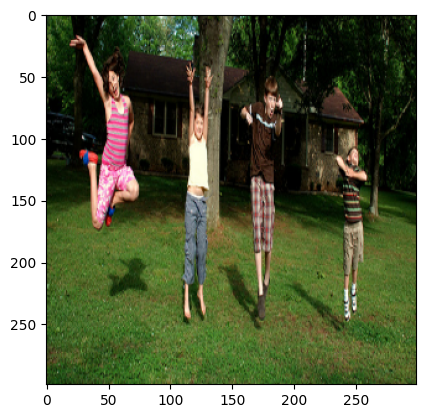

Predicted Caption:  two girls in pink dresses and pink shirts are playing with a tree


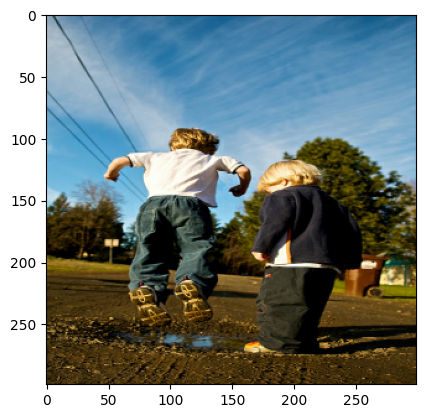

Predicted Caption:  a boy is jumping off a ramp


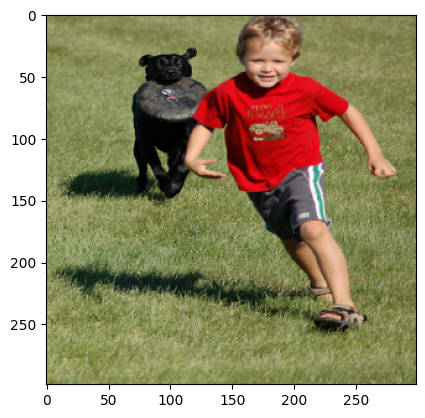

Predicted Caption:  a boy in a red shirt runs through the grass


In [12]:
vocab = vectorization.get_vocabulary()
index_lookup = dict(zip(range(len(vocab)), vocab))
max_decoded_sentence_length = seq_length - 1
valid_images = list(val_data.keys())


def generate_caption():
    # Select a random image from the validation dataset
    sample_img = np.random.choice(valid_images)

    # Read the image from the disk
    sample_img = decode_and_resize(sample_img)
    img = sample_img.numpy().clip(0, 255).astype(np.uint8)
    plt.imshow(img)
    plt.show()

    # Pass the image to the CNN
    img = tf.expand_dims(sample_img, 0)
    img = caption_model.cnn_model(img)

    # Pass the image features to the Transformer encoder
    encoded_img = caption_model.encoder(img, training=False)

    # Generate the caption using the Transformer decoder
    decoded_caption = "<start> "
    for i in range(max_decoded_sentence_length):
        tokenized_caption = vectorization([decoded_caption])[:, :-1]
        mask = tf.math.not_equal(tokenized_caption, 0)
        predictions = caption_model.decoder(
            tokenized_caption, encoded_img, training=False, mask=mask
        )
        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = index_lookup[sampled_token_index]
        if sampled_token == "<end>":
            break
        decoded_caption += " " + sampled_token

    decoded_caption = decoded_caption.replace("<start> ", "")
    decoded_caption = decoded_caption.replace(" <end>", "").strip()
    print("Predicted Caption: ", decoded_caption)


# Check predictions for a few samples
generate_caption()
generate_caption()
generate_caption()
